modo 1
[[[1269. 1655.]]

 [[ 641. 2934.]]

 [[1580. 3400.]]

 [[2156. 2050.]]]
[[[1269. 1655.]]

 [[2156. 2050.]]

 [[1580. 3400.]]

 [[ 641. 2934.]]]
[[  0.   0.]
 [146.   0.]
 [146. 204.]
 [  0. 204.]]


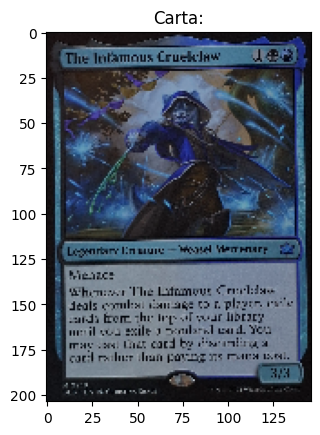

In [3]:
from matplotlib.axis import XAxis
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = "./RealImg/carta2.jpg"

imgBGR = cv2.imread(path, cv2.IMREAD_COLOR)
imgRGB = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2RGB)
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

img = cv2.GaussianBlur(img, (7, 7), 0)

img = cv2.adaptiveThreshold(img, 255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
img = cv2.bitwise_not(img)

conts, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

card = None
for c in conts:
  epsilon = 0.02 * cv2.arcLength(c, True)
  approx = cv2.approxPolyDP(c, epsilon, True)
  if len(approx) == 4:
    if card is None:
      card = approx
    elif int(cv2.contourArea(c))>int(cv2.contourArea(card)):
      card = approx

pts = np.float32([card[0],card[1], card[2],card[3]])

if card[1][0][1] > card[3][0][1]:
  print("modo 1")
  pts1 = np.float32([card[0],card[3], card[2],card[1]])
else:
  print("modo 2")
  pts1 = np.float32([card[1],card[0], card[3],card[2]])

pts2 = np.float32([[0,0],[146,0],[146,204],[0,204]])

print(pts)
print(pts1)
print(pts2)

cv2.circle(img, card[0][0], 5, 255, 20)
cv2.circle(img, card[1][0], 5, 255, 20)
cv2.circle(img, card[2][0], 5, 255, 20)
cv2.circle(img, card[3][0], 5, 255, 20)

#plt.subplot(111), plt.title("Carta:"), plt.axis("on")
#plt.imshow(img)

M = cv2.getPerspectiveTransform(pts1, pts2)
img = cv2.warpPerspective(imgBGR, M, (146,204))

cv2.imwrite("./RealImg/carta2Tratada.jpg",img)

plt.subplot(111), plt.title("Carta:"), plt.axis("on")
plt.imshow(img)